In [48]:
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns

In [49]:
data_folder = 'data'

all_csv_paths = []
for dirpath, dirnames, filenames in os.walk(data_folder):
    for filename in filenames:
        if filename.endswith('.csv'):
            all_csv_paths.append((os.path.join(dirpath, filename), filename))

In [50]:
def make_df_list(csv_paths, keyword):
    dfs = []
    for full_path, filename in csv_paths:
        if keyword in filename:
            df = pd.read_csv(full_path)

            if 'running' in filename:
                df['activity_label'] = 0
            
            elif 'rowing' in filename:
                df['activity_label'] = 1

            elif 'jumpingjacks' in filename:
                df['activity_label'] = 2

            elif 'lifting' in filename:
                df['activity_label'] = 3

            dfs.append(df)
    return dfs

In [51]:
dfs_20Hz_hand = make_df_list(all_csv_paths, '20Hz-hand')
dfs_20Hz_pocket = make_df_list(all_csv_paths, '20Hz-pocket')
dfs_100Hz_hand = make_df_list(all_csv_paths, '100Hz-hand')
dfs_100Hz_pocket = make_df_list(all_csv_paths, '100Hz-pocket')

all_df_lists = {
    '20Hz_hand': dfs_20Hz_hand,
    '20Hz_pocket': dfs_20Hz_pocket,
    '100Hz_hand': dfs_100Hz_hand,
    '100Hz_pocket': dfs_100Hz_pocket
}

In [52]:
print(len(dfs_20Hz_hand))
print(len(dfs_20Hz_pocket))
print(len(dfs_100Hz_hand))
print(len(dfs_100Hz_pocket))

212
190
191
190


In [53]:
def radian_or_degree(df):
    for col in df.columns:
        if 'gyro' in col:
            if df[col].abs().max() > 100:
                return 'degree'
    return 'radian'


def degree_to_radian(df):
    for col in df.columns:
        if 'gyro' in col:
            df[col] = np.deg2rad(df[col])
    return df

In [54]:
for dfs in all_df_lists.values():
    for df in dfs:
        df.dropna()

for dfs in all_df_lists.values():
    for df in dfs:
        if radian_or_degree(df) == 'degree':
            df = degree_to_radian(df)

In [55]:
for df in dfs_20Hz_hand:
    if radian_or_degree(df) == 'degree':
        print('still degree')

print('everything checked')

everything checked


In [56]:
dfs_20Hz_hand[0].head()

,id,timestamp,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity_label
0,1,1.778591e+09,-6.207352,1.385513,-1.728902,-0.395213,0.096939,2.800580,2
1,2,1.778591e+09,-3.385806,-0.283595,1.610046,-3.393400,-4.149738,4.316984,2
2,3,1.778591e+09,-2.509397,-1.178308,1.921707,0.048470,-4.837366,5.885586,2
3,4,1.778591e+09,-2.469859,-1.844097,0.382194,5.854693,-0.355798,8.094945,2
4,5,1.778591e+09,-2.305365,-2.075951,0.216967,5.471198,0.165116,8.841695,2


Standardizations

In [ ]:
scaler = StandardScaler()

scaled_dfs_20Hz_hand = []
scaled_dfs_20Hz_pocket = []
scaled_dfs_100Hz_hand = []
scaled_dfs_100Hz_pocket = []

all_scaled_df_lists = {
    '20Hz_hand': scaled_dfs_20Hz_hand,
    '20Hz_pocket': scaled_dfs_20Hz_pocket,
    '100Hz_hand': scaled_dfs_100Hz_hand,
    '100Hz_pocket': scaled_dfs_100Hz_pocket
}

cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_df_lists.items():
    for df in dfs:
        scaler.fit(df[cols_to_scale])
        scaled_tmp = scaler.transform(df[cols_to_scale])
        scaled_df = df.copy()
        scaled_df[cols_to_scale] = scaled_tmp
        all_scaled_df_lists[key].append(scaled_df)

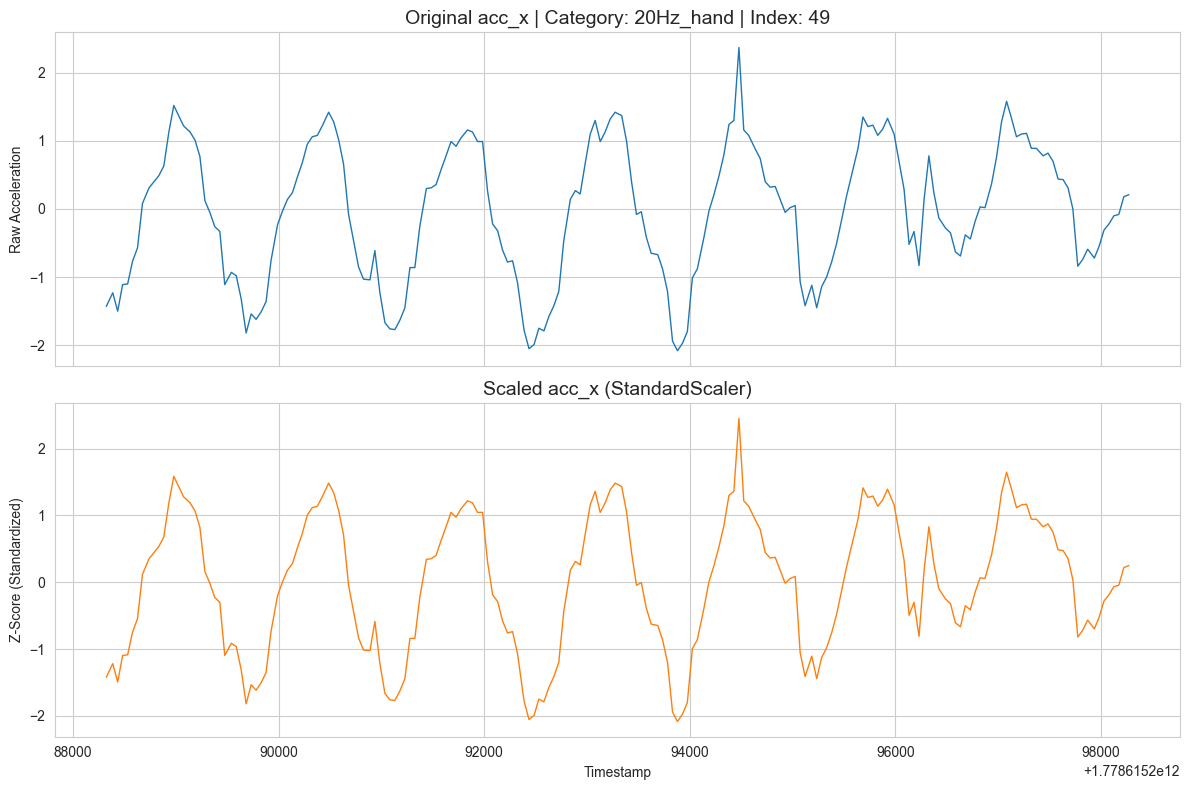

In [63]:
import random
import matplotlib.pyplot as plt

random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_df_lists[random_key][random_idx]
df_scaled = all_scaled_df_lists[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Original acc_x | Category: {random_key} | Index: {random_idx}', fontsize=14)
ax1.set_ylabel('Raw Acceleration')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

In [62]:
ts_normalized_20Hz_hand = []
ts_normalized_20Hz_pocket = []
ts_normalized_100Hz_hand = []
ts_normalized_100Hz_pocket = []

all_timestamp_normaized_dfs = {
    '20Hz_hand': ts_normalized_20Hz_hand,
    '20Hz_pocket': ts_normalized_20Hz_pocket,
    '100Hz_hand': ts_normalized_100Hz_hand,
    '100Hz_pocket': ts_normalized_100Hz_pocket
}

for key, dfs in all_df_lists.items():
    for df in dfs:
        min_timestamp = df['timestamp'].min()
        df_tmp = df.copy()
        df_tmp['timestamp'] = (df_tmp['timestamp'] - min_timestamp)
        all_timestamp_normaized_dfs[key].append(df_tmp)

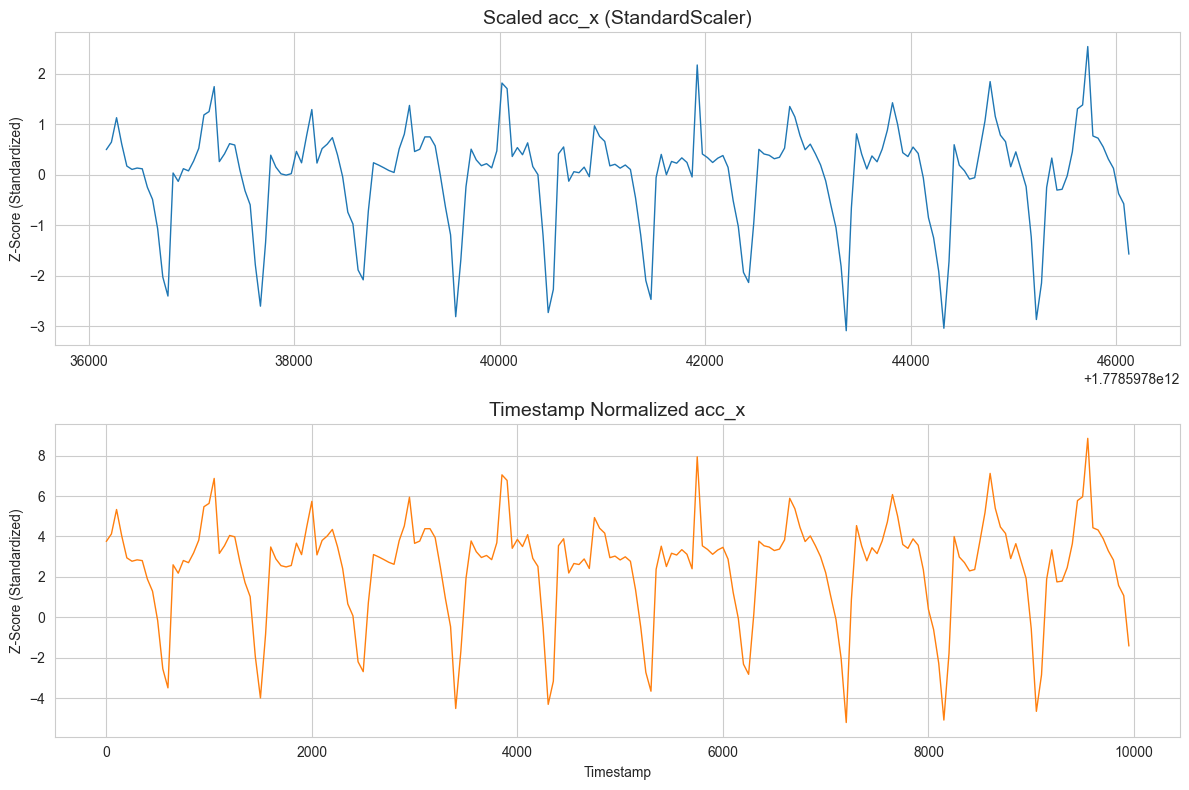

In [70]:
random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_scaled_df_lists[random_key][random_idx]
df_scaled = all_timestamp_normaized_dfs[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax1.set_ylabel('Z-Score (Standardized)')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Timestamp Normalized acc_x', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

In [71]:
scaler = MinMaxScaler()

normalized_dfs_20Hz_hand = []
normalized_dfs_20Hz_pocket = []
normalized_dfs_100Hz_hand = []
normalized_dfs_100Hz_pocket = []

all_normalized_df_lists = {
    '20Hz_hand': normalized_dfs_20Hz_hand,
    '20Hz_pocket': normalized_dfs_20Hz_pocket,
    '100Hz_hand': normalized_dfs_100Hz_hand,
    '100Hz_pocket': normalized_dfs_100Hz_pocket
}

cols_to_scale = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_timestamp_normaized_dfs.items():
    for df in dfs:
        scaler.fit(df[cols_to_scale])
        normalized_tmp = scaler.transform(df[cols_to_scale])
        normalized_df = df.copy()
        normalized_df[cols_to_scale] = normalized_tmp
        all_normalized_df_lists[key].append(normalized_df)

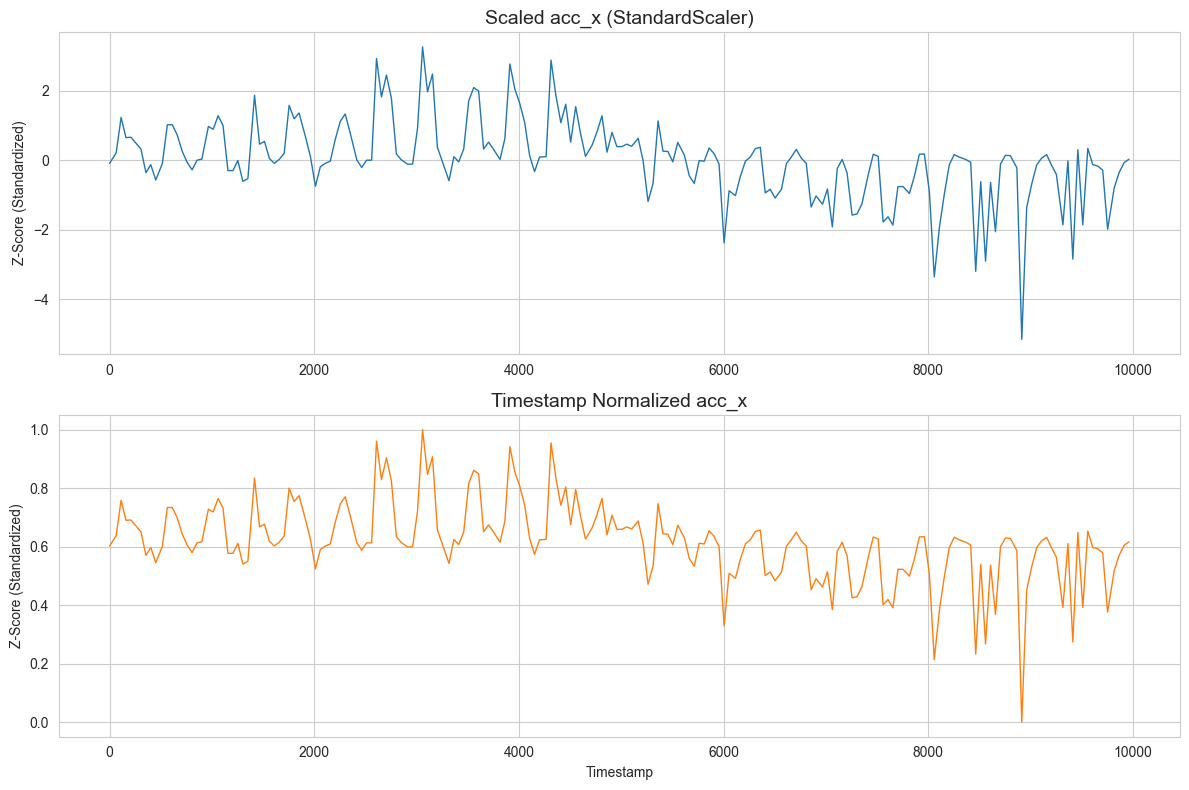

In [72]:
random_key = random.choice(list(all_df_lists.keys()))
random_idx = random.randrange(len(all_df_lists[random_key]))

df_original = all_timestamp_normaized_dfs[random_key][random_idx]
df_scaled = all_normalized_df_lists[random_key][random_idx]

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

# Plot Original Data
ax1.plot(df_original['timestamp'], df_original['acc_x'], color='#1f77b4', linewidth=1)
ax1.set_title(f'Scaled acc_x (StandardScaler)', fontsize=14)
ax1.set_ylabel('Z-Score (Standardized)')

# Plot Scaled Data
ax2.plot(df_scaled['timestamp'], df_scaled['acc_x'], color='#ff7f0e', linewidth=1)
ax2.set_title(f'Timestamp Normalized acc_x', fontsize=14)
ax2.set_ylabel('Z-Score (Standardized)')
ax2.set_xlabel('Timestamp')

plt.tight_layout()
plt.show()

# Feature Extraction

In [80]:
def get_median_amplitude(df, col):
    return df[col].median()


def get_std(df, col):
    return df[col].std()


def get_dominant_frequency(df, col, sampling_rate):
    n = len(df)
    freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(np.fft.rfft(df[col]))

    dominant_freq = freqs[1:][np.argmax(fft_magnitude[1:])]
    return dominant_freq

In [73]:
def append_values_to_dict(dict, activity_label, col_features):
    dict['activity_label'].append(activity_label)
    for feature_name, feature_value in col_features.items():
        dict[feature_name].append(feature_value)

In [ ]:
import copy
dict_template = {'activity_label': [],
                 'acc_x_median': [], 'acc_x_std': [], 'acc_x_dominant_freq': [],
                 'acc_y_median': [], 'acc_y_std': [], 'acc_y_dominant_freq': [],
                 'acc_z_median': [], 'acc_z_std': [], 'acc_z_dominant_freq': [],
                 'gyro_x_median': [], 'gyro_x_std': [], 'gyro_x_dominant_freq': [],
                 'gyro_y_median': [], 'gyro_y_std': [], 'gyro_y_dominant_freq': [],
                 'gyro_z_median': [], 'gyro_z_std': [], 'gyro_z_dominant_freq': []}

features_20Hz_hand_dict = copy.deepcopy(dict_template)
features_20Hz_pocket_dict = copy.deepcopy(dict_template)
features_100Hz_hand_dict = copy.deepcopy(dict_template)
features_100Hz_pocket_dict = copy.deepcopy(dict_template)

cols_to_evaluate = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for key, dfs in all_normalized_df_lists.items():

    for df in dfs:

        activity = df['activity_label'].iloc[0]

        sampling_rate = None
        if '20Hz' in key:
            sampling_rate = 20
        elif '100Hz' in key:
            sampling_rate = 100

        col_features = {}

        for col in cols_to_evaluate:
            median_amplitude = get_median_amplitude(df, col)
            std = get_std(df, col)
            dominant_freq = get_dominant_frequency(df, col, sampling_rate)

            col_features[f'{col}_median'] = median_amplitude
            col_features[f'{col}_std'] = std
            col_features[f'{col}_dominant_freq'] = dominant_freq
        
        match key:
            case '20Hz_hand':
                append_values_to_dict(features_20Hz_hand_dict, activity, col_features)
            
            case '20Hz_pocket':
                append_values_to_dict(features_20Hz_pocket_dict, activity, col_features)
            
            case '100Hz_hand':
                append_values_to_dict(features_100Hz_hand_dict, activity, col_features)

            case '100Hz_pocket':
                append_values_to_dict(features_100Hz_pocket_dict, activity, col_features)

In [ ]:
features_20Hz_hand_df = pd.DataFrame(features_20Hz_hand_dict)
features_20Hz_pocket_df = pd.DataFrame(features_20Hz_pocket_dict)
features_100Hz_hand_df = pd.DataFrame(features_100Hz_hand_dict)
features_100Hz_pocket_df = pd.DataFrame(features_100Hz_pocket_dict)

In [88]:
features_20Hz_hand_df.head()

,activity_label,acc_x_median,acc_x_std,acc_x_dominant_freq,acc_y_median,acc_y_std,acc_y_dominant_freq,acc_z_median,acc_z_std,acc_z_dominant_freq,gyro_x_median,gyro_x_std,gyro_x_dominant_freq,gyro_y_median,gyro_y_std,gyro_y_dominant_freq,gyro_z_median,gyro_z_std,gyro_z_dominant_freq
0,2,0.409023,0.205361,1.25,0.435682,0.174436,1.25,0.530218,0.155825,0.125,0.520067,0.202716,1.25,0.450810,0.178421,1.250,0.455059,0.309248,1.25
1,2,0.400871,0.194977,1.25,0.447617,0.198586,1.25,0.546952,0.188371,1.250,0.449711,0.215417,1.25,0.528756,0.187427,2.625,0.442819,0.312196,1.25
2,2,0.484451,0.182196,1.25,0.442929,0.197596,1.25,0.449546,0.209802,1.250,0.461769,0.241119,1.25,0.427027,0.207525,2.500,0.488056,0.294404,1.25
3,2,0.420712,0.198789,1.25,0.397877,0.190461,1.25,0.359885,0.146887,1.250,0.468294,0.198086,1.25,0.443577,0.212933,2.500,0.433880,0.326648,1.25
4,2,0.468400,0.184355,1.25,0.409778,0.179377,1.25,0.531448,0.207747,1.250,0.686683,0.202215,1.25,0.561159,0.199075,1.250,0.628194,0.318572,1.25


In [84]:
features_100Hz_hand_df.tail()

,activity_label,acc_x_median,acc_x_std,acc_x_dominant_freq,acc_y_median,acc_y_std,acc_y_dominant_freq,acc_z_median,acc_z_std,acc_z_dominant_freq,gyro_x_median,gyro_x_std,gyro_x_dominant_freq,gyro_y_median,gyro_y_std,gyro_y_dominant_freq,gyro_z_median,gyro_z_std,gyro_z_dominant_freq
778,2,0.349093,0.112401,5.894106,0.739981,0.211028,1.898102,0.313883,0.088457,1.898102,0.389323,0.173962,1.998002,0.414940,0.126443,1.998002,0.611179,0.150740,0.999001
779,2,0.452125,0.133043,0.999001,0.640581,0.214691,1.998002,0.428307,0.163858,0.999001,0.380577,0.193381,1.998002,0.424778,0.144992,1.998002,0.507017,0.154193,0.999001
780,2,0.336354,0.131929,0.999001,0.776677,0.172956,1.998002,0.413810,0.122447,0.999001,0.428744,0.196759,1.998002,0.471497,0.139659,6.993007,0.513512,0.175119,0.999001
781,2,0.461594,0.117991,1.998002,0.714545,0.221933,1.998002,0.477008,0.114201,1.998002,0.322403,0.171844,1.998002,0.433119,0.138434,0.999001,0.562716,0.181216,0.999001
782,2,0.391906,0.122694,1.998002,0.684610,0.235524,1.998002,0.439391,0.120479,1.998002,0.386387,0.183646,1.998002,0.508728,0.116732,0.999001,0.603657,0.163410,0.999001


In [85]:
features_100Hz_hand_df['activity_label'].value_counts()

activity_label
0    222
2    201
3    180
1    180
Name: count, dtype: int64